In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA

from sklearn.metrics import confusion_matrix, precision_score, recall_score

In [12]:
df = pd.read_csv("creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [13]:
print(df.shape)

(284807, 31)


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [15]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


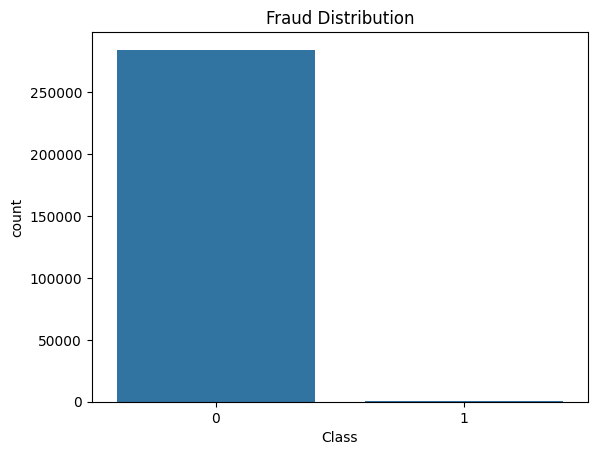

In [16]:
sns.countplot(x="Class", data=df)
plt.title("Fraud Distribution")
plt.show()

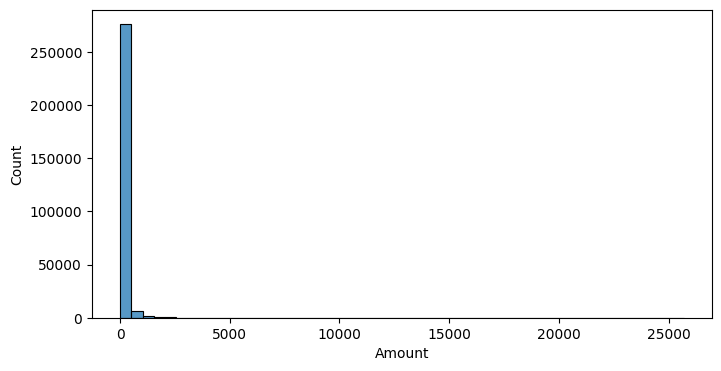

In [17]:
plt.figure(figsize=(8,4))
sns.histplot(df["Amount"], bins=50)
plt.show()

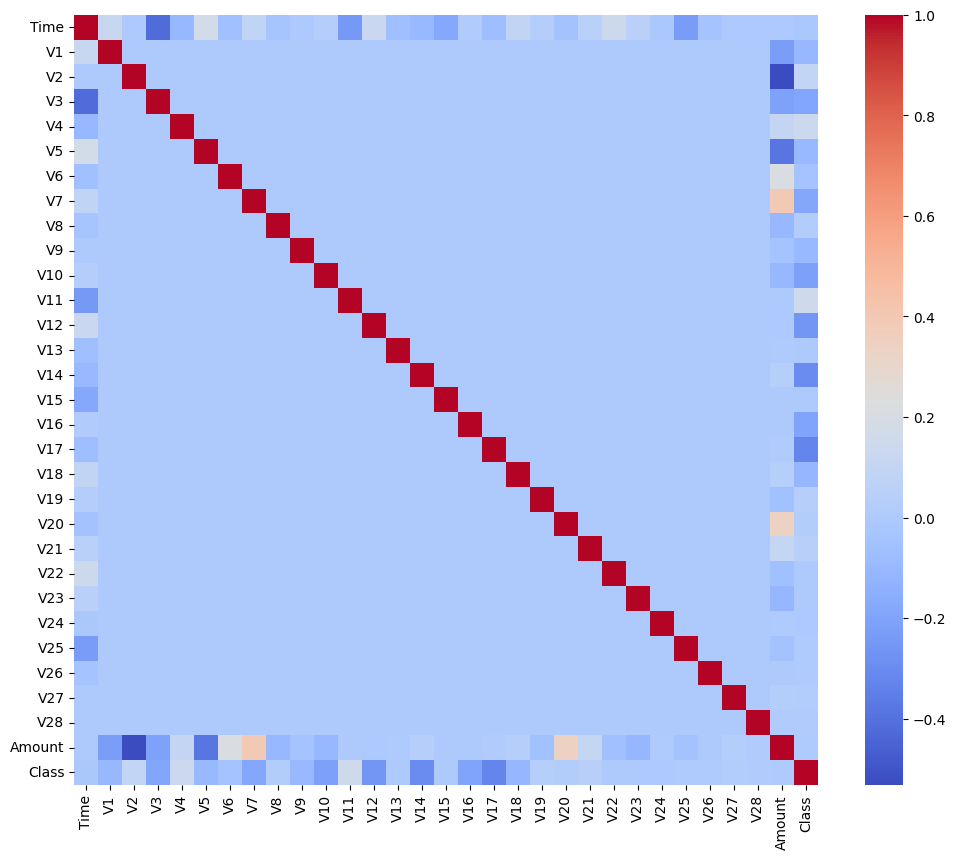

In [18]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.show()

In [19]:
scaler = StandardScaler()

df["Amount"] = scaler.fit_transform(df[["Amount"]])
df["Time"] = scaler.fit_transform(df[["Time"]])

In [20]:
X = df.drop("Class", axis=1)

y = df["Class"]

In [21]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

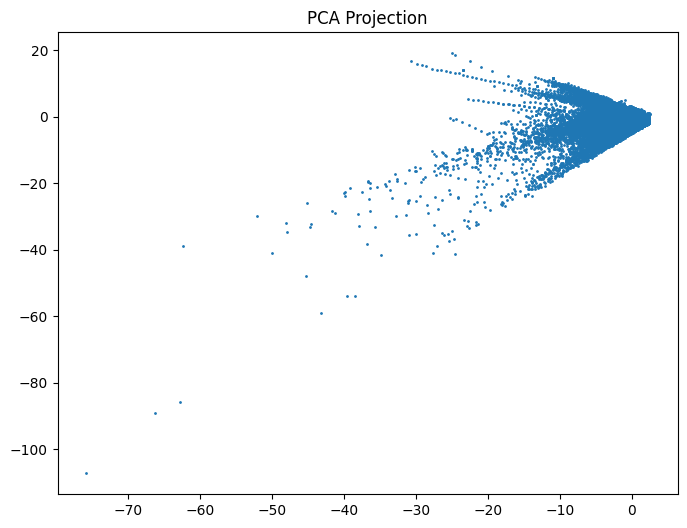

In [22]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], s=1)
plt.title("PCA Projection")
plt.show()

In [23]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42
)

clusters = kmeans.fit_predict(X)

In [24]:
pd.Series(clusters).value_counts()

,count
0,268757
1,16050


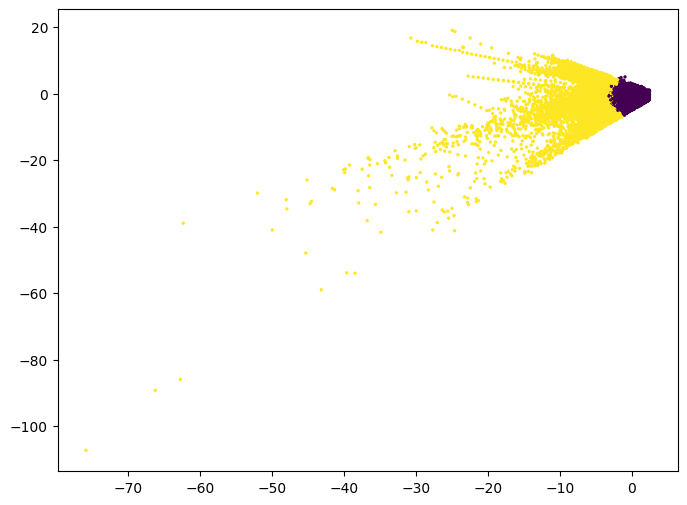

In [25]:
plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    s=2,
    cmap="viridis"
)

plt.show()

In [26]:
iso = IsolationForest(
    contamination=0.0017,
    random_state=42
)

pred = iso.fit_predict(X)

In [27]:
pred = np.where(pred==-1,1,0)

In [28]:
pd.Series(pred).value_counts()

,count
0,284322
1,485


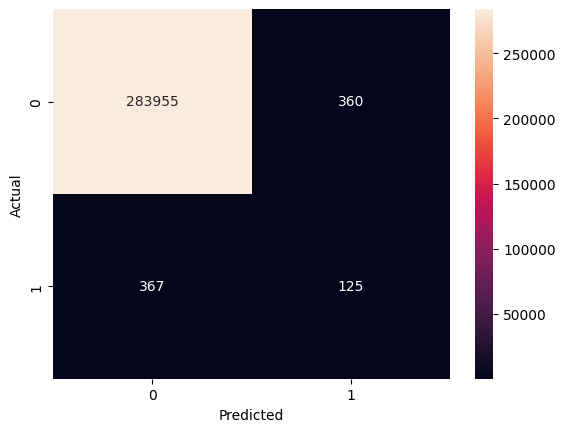

In [29]:
cm = confusion_matrix(y,pred)

sns.heatmap(cm,
            annot=True,
            fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [30]:
precision = precision_score(y,pred)

print("Precision:",precision)

Precision: 0.25773195876288657


In [31]:
recall = recall_score(y,pred)

print("Recall:",recall)

Recall: 0.2540650406504065


Isolation Forest performed better because fraud transactions behave as anomalies rather than clusters.

K-Means assumes spherical clusters and is sensitive to imbalance.

Isolation Forest isolates rare observations efficiently, making it more suitable for fraud detection.

## Conclusion

This project implemented two unsupervised learning methods for fraud detection.

K-Means grouped transactions into clusters but struggled with the highly imbalanced dataset.

Isolation Forest successfully detected anomalous transactions because it is specifically designed for anomaly detection.

Although no labels were used during model training, evaluation against the actual fraud labels showed that Isolation Forest is a more effective technique for real-world fraud detection.

Recommendation:
Financial institutions should use Isolation Forest as an initial screening model to flag suspicious transactions for further investigation.